In [1]:
import cv2 as cv
import numpy as np
from bordas import det_roberts, det_prewitt, det_sobel, det_scharr, det_laplaciano, det_LoG, det_DoG, det_canny
from funcoespi import exibir_resultados

In [2]:
# Carregar imagem
estrada_bgr = cv.imread('data/estrada.png')

# Implementação de Roberts

In [3]:
# Implementação Opencv
estrada_manual_roberts = det_roberts(estrada_bgr)

# Implementação OpenCV (simulando Roberts com filter2D)
gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY).astype(np.float64)
kernel_gx = np.array([[1, 0], [0, -1]], dtype=np.float64)
kernel_gy = np.array([[0, 1], [-1, 0]], dtype=np.float64)

gx = cv.filter2D(gray, -1, kernel_gx)
gy = cv.filter2D(gray, -1, kernel_gy)
magnitude = np.sqrt(gx ** 2 + gy ** 2)
estrada_opencv_roberts = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

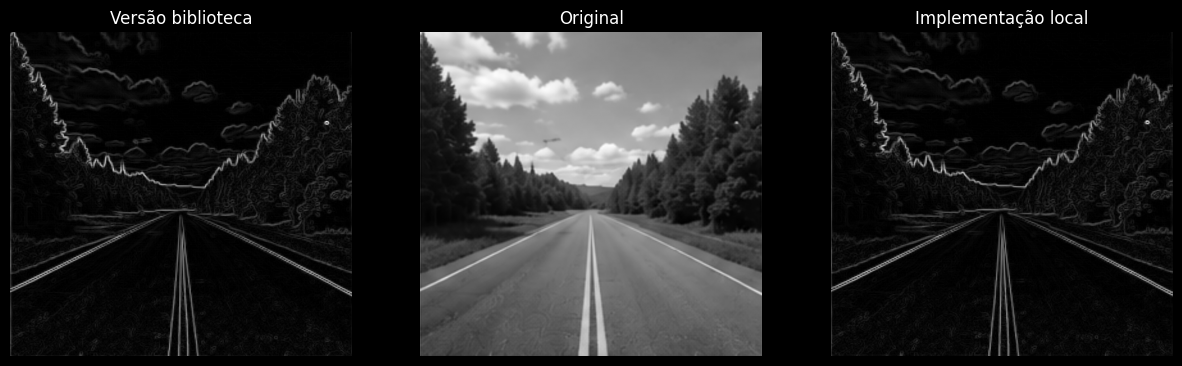

In [4]:
# Exibição em Grayscale
exibir_resultados(estrada_opencv_roberts, estrada_bgr, estrada_manual_roberts)


# Implementação de Prewitt

In [5]:
# Implementação Manual
estrada_manual_prewitt = det_prewitt(estrada_bgr)

# Implementação OpenCV usando filter2D
gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY).astype(np.float32)

kernel_gx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

kernel_gy = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32)

gx = cv.filter2D(gray, -1, kernel_gx)
gy = cv.filter2D(gray, -1, kernel_gy)

magnitude = np.sqrt(gx ** 2 + gy ** 2)

estrada_opencv_prewitt = cv.normalize(
    magnitude, None, 0, 255, cv.NORM_MINMAX
).astype(np.uint8)

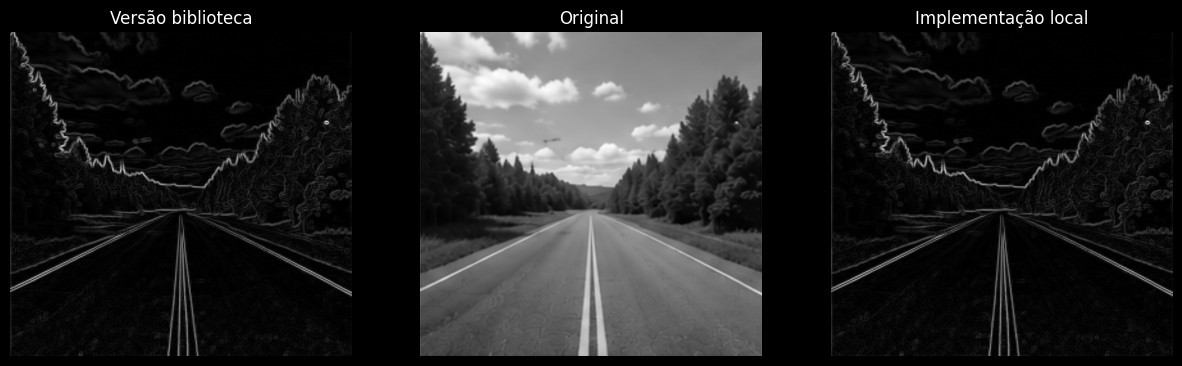

In [6]:
exibir_resultados(estrada_opencv_prewitt, estrada_bgr, estrada_manual_prewitt)

# Implementação de Sobel

In [7]:
# Implementação Manual
estrada_manual_sobel = det_sobel(estrada_bgr)

# Implementação OpenCV usando Sobel

gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY)
sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(sobelx ** 2 + sobely ** 2)
estrada_opencv_sobel = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

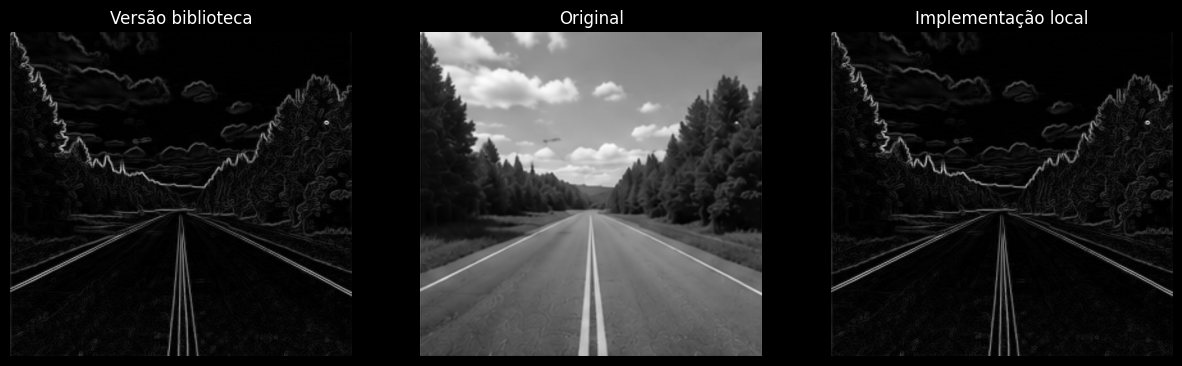

In [8]:
exibir_resultados(estrada_opencv_sobel, estrada_bgr, estrada_manual_sobel)

# Implementação de Scharr

In [9]:
# Implementação Cv2
def cv_scharr(img):
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    gx = cv.Scharr(img_gray, cv.CV_64F, 1, 0)
    gy = cv.Scharr(img_gray, cv.CV_64F, 0, 1)

    magnitude = cv.magnitude(gx, gy)

    magnitude = cv.normalize(
        magnitude,
        None,
        0,
        255,
        cv.NORM_MINMAX
    )

    return magnitude.astype(np.uint8)

In [10]:
estrada_opencv_scharr = cv_scharr(estrada_bgr)

estrada_manual_scharr = det_scharr(estrada_bgr)

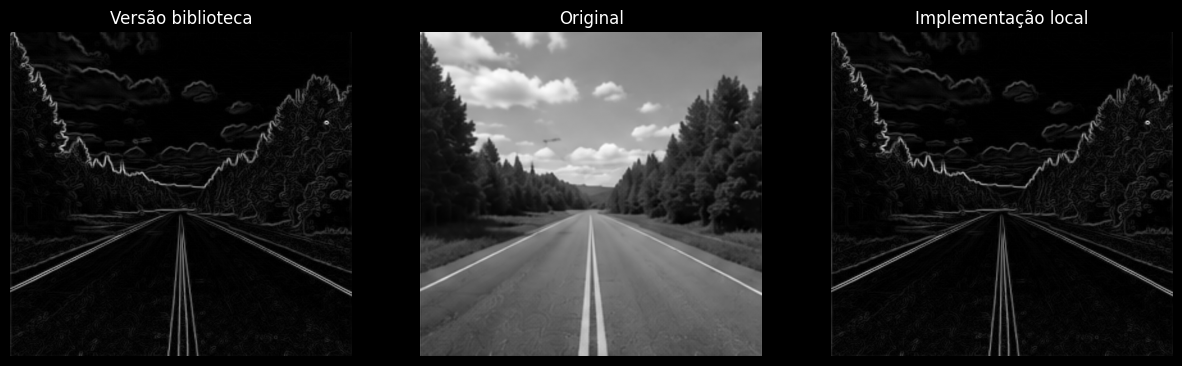

In [11]:
exibir_resultados(estrada_opencv_scharr, estrada_bgr, estrada_manual_scharr)

# Implementação de Laplaciano

In [12]:
# Implementação Manual
estrada_manual_laplaciano = det_laplaciano(estrada_bgr)

# Implementação OpenCV usando Laplacian
def det_laplaciano_opencv(img):
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    lap = cv.Laplacian(img_gray, cv.CV_64F)

    lap = np.abs(lap)

    lap = cv.normalize(
        lap,
        None,
        0,
        255,
        cv.NORM_MINMAX
    )

    return lap.astype(np.uint8)

estrada_opencv_laplaciano = det_laplaciano_opencv(estrada_bgr)

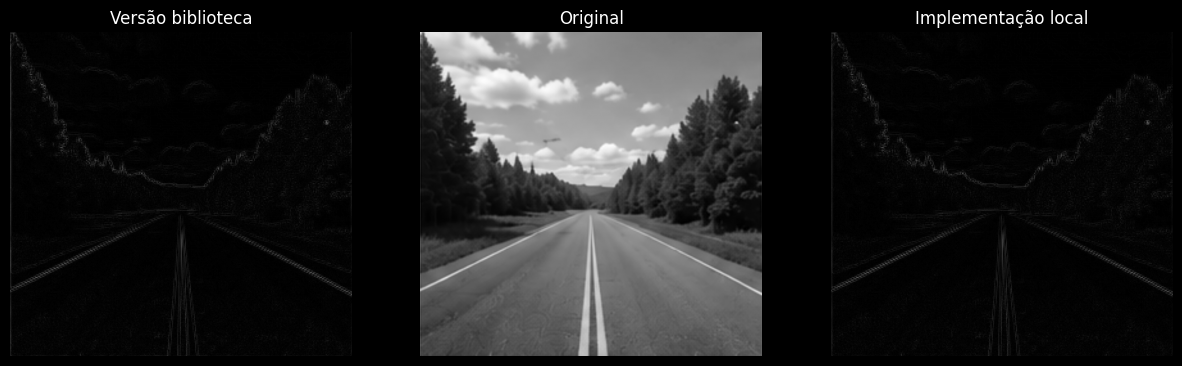

In [13]:
exibir_resultados(estrada_opencv_laplaciano, estrada_bgr, estrada_manual_laplaciano)

# Implementação de det_LoG

In [14]:
# Implentação OpenCv
def log_opencv(img):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    blur = cv.GaussianBlur(
        gray,
        (5, 5),
        sigmaX=0
    )

    log = cv.Laplacian(
        blur,
        cv.CV_64F,
        ksize=3
    )

    log = np.abs(log)

    log = cv.normalize(
        log,
        None,
        0,
        255,
        cv.NORM_MINMAX
    )

    return log.astype(np.uint8)

In [15]:
# Implementação Local
estrada_manual_det_LoG = det_LoG(estrada_bgr)

# Implemntação Opencv
estrada_opencv_log_opencv = log_opencv(estrada_bgr)

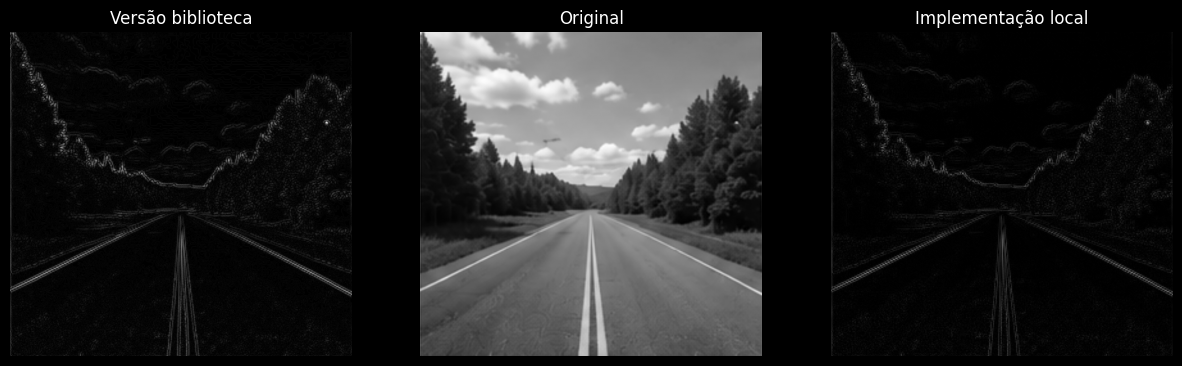

In [16]:
exibir_resultados(estrada_opencv_log_opencv, estrada_bgr, estrada_manual_det_LoG)

# Implementação Dog

In [17]:
def det_DoG_cv(img):
    gray = cv.cvtColor(
        img,
        cv.COLOR_BGR2GRAY
    ).astype(np.float64)

    g1 = cv.GaussianBlur(
        gray,
        (3, 3),
        0
    )

    g2 = cv.GaussianBlur(
        gray,
        (7, 7),
        0
    )

    dog = g1 - g2

    dog = np.abs(dog)

    dog = cv.normalize(
        dog,
        None,
        0,
        255,
        cv.NORM_MINMAX
    )

    return dog.astype(np.uint8)

In [18]:
# Implementação Local
estrada_manual_det_dog = det_DoG(estrada_bgr)
# Implemntação Opencv
estrada_opencv_dog_opencv = det_DoG_cv(estrada_bgr)

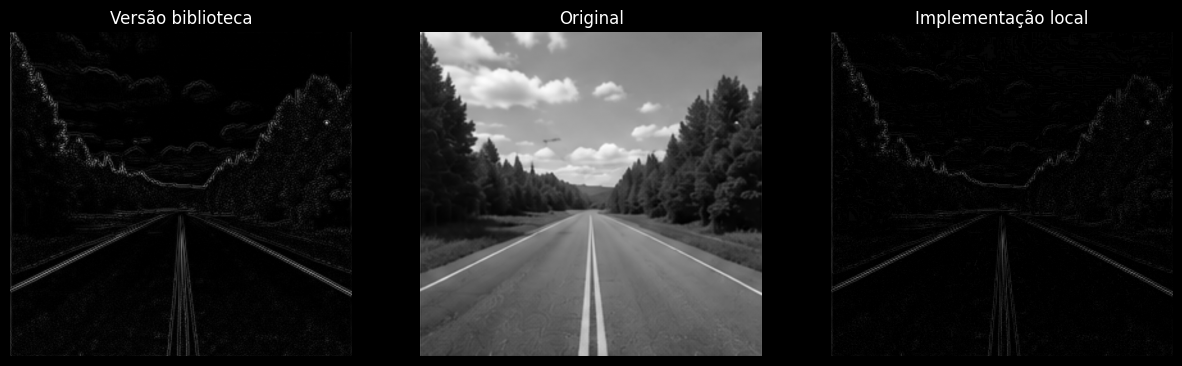

In [19]:
exibir_resultados(estrada_opencv_dog_opencv,estrada_bgr, estrada_manual_det_dog)

# Implementação Canny

In [20]:
def det_canny_cv(img,
                 low_threshold=50,
                 high_threshold=150):

    img_gray = cv.cvtColor(
        img,
        cv.COLOR_BGR2GRAY
    )

    return cv.Canny(
        img_gray,
        low_threshold,
        high_threshold
    )

In [21]:
# Implementação Local
estrada_manual_det_canny = det_canny(estrada_bgr)
# Implemntação Opencv
estrada_opencv_canny_opencv = det_canny_cv(estrada_bgr)

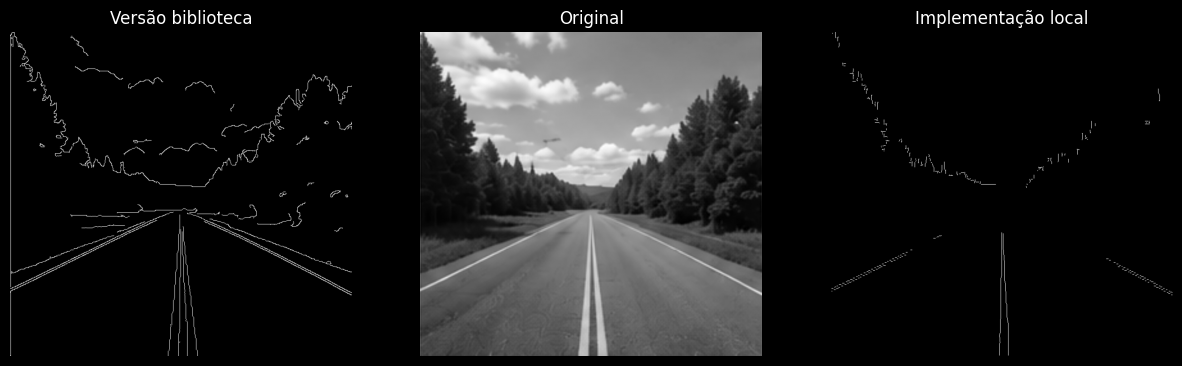

In [22]:
exibir_resultados(estrada_opencv_canny_opencv,estrada_bgr, estrada_manual_det_canny)